<a href="https://colab.research.google.com/github/k2herat/MMK/blob/first_task/almetov_mmk_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 1: Монте-Карло и машинное обучение


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [ ]:
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


1. **Ridge Regression** (Линейная модель с L2 регуляризацией)
2. **Gradient Boosting** (Градиентный бустинг над деревьями)

In [ ]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {'ridge__alpha': np.logspace(-3, 3, 50)}
ridge_search = RandomizedSearchCV(ridge_pipe, ridge_params, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_

gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingRegressor(random_state=42))
])

gb_params = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5, 7],
    'gb__learning_rate': [0.01, 0.1, 0.2]
}
gb_search = RandomizedSearchCV(gb_pipe, gb_params, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

print(f"Лучшие параметры Ridge: {ridge_search.best_params_}")
print(f"Лучшие параметры Gradient Boosting: {gb_search.best_params_}")

Лучшие параметры Ridge: {'ridge__alpha': np.float64(0.002329951810515372)}
Лучшие параметры Gradient Boosting: {'gb__n_estimators': 200, 'gb__max_depth': 7, 'gb__learning_rate': 0.1}


In [ ]:
def run_monte_carlo(model, X_trn, y_trn, X_tst, n_simulations=30):
    predictions = np.zeros((n_simulations, len(X_tst)))

    for i in tqdm(range(n_simulations), desc=f"Монте-Карло ({model.steps[-1][0]})"):
        X_boot, y_boot = resample(X_trn, y_trn, replace=True, random_state=i)

        model.fit(X_boot, y_boot)


        predictions[i, :] = model.predict(X_tst)

    preds_mean = predictions.mean(axis=0)
    preds_std = predictions.std(axis=0)


    ci_lower = preds_mean - 1.96 * preds_std
    ci_upper = preds_mean + 1.96 * preds_std

    return preds_mean, ci_lower, ci_upper


ridge_mc_mean, ridge_ci_lower, ridge_ci_upper = run_monte_carlo(best_ridge, X_train, y_train, X_test, n_simulations=30)
gb_mc_mean, gb_ci_lower, gb_ci_upper = run_monte_carlo(best_gb, X_train, y_train, X_test, n_simulations=30)

Монте-Карло (ridge):   0%|          | 0/30 [00:00<?, ?it/s]

Монте-Карло (gb):   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:

best_ridge.fit(X_train, y_train)
best_gb.fit(X_train, y_train)

ridge_base_pred = best_ridge.predict(X_test)
gb_base_pred = best_gb.predict(X_test)

metrics = {
    'Модель / Подход': [
        'Ridge (Базовая)', 'Ridge (Монте-Карло)',
        'Gradient Boosting (Базовая)', 'Gradient Boosting (Монте-Карло)'
    ],
    'MSE': [
        mean_squared_error(y_test, ridge_base_pred),
        mean_squared_error(y_test, ridge_mc_mean),
        mean_squared_error(y_test, gb_base_pred),
        mean_squared_error(y_test, gb_mc_mean)
    ],
    'R²': [
        r2_score(y_test, ridge_base_pred),
        r2_score(y_test, ridge_mc_mean),
        r2_score(y_test, gb_base_pred),
        r2_score(y_test, gb_mc_mean)
    ]
}

metrics_df = pd.DataFrame(metrics).round(4)
display(metrics_df)

,Модель / Подход,MSE,R²
0,Ridge (Базовая),0.5559,0.5758
1,Ridge (Монте-Карло),0.5562,0.5756
2,Gradient Boosting (Базовая),0.2071,0.8420
3,Gradient Boosting (Монте-Карло),0.2035,0.8447


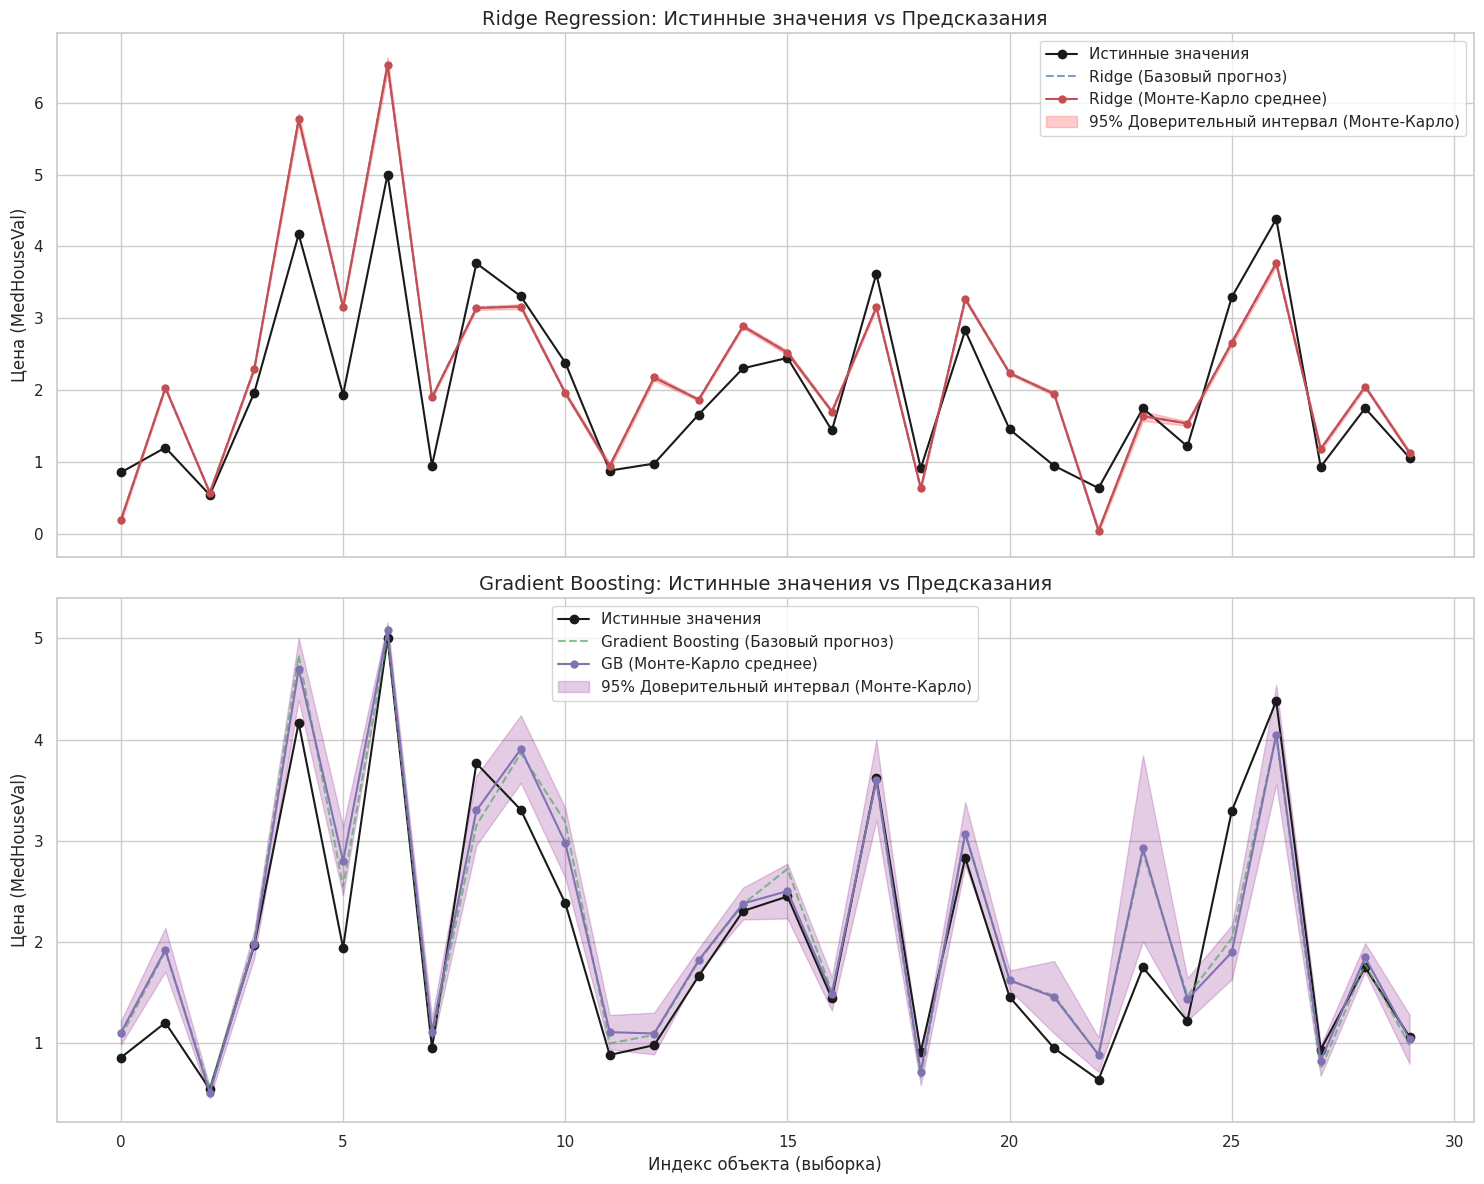

In [ ]:

np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=30, replace=False)
sample_idx.sort()

y_true_sample = y_test.iloc[sample_idx].values
x_axis = np.arange(len(sample_idx))

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)


axes[0].plot(x_axis, y_true_sample, 'ko-', label='Истинные значения', markersize=6)
axes[0].plot(x_axis, ridge_base_pred[sample_idx], 'b--', label='Ridge (Базовый прогноз)', alpha=0.7)
axes[0].plot(x_axis, ridge_mc_mean[sample_idx], 'ro-', label='Ridge (Монте-Карло среднее)', markersize=5)
axes[0].fill_between(x_axis, ridge_ci_lower[sample_idx], ridge_ci_upper[sample_idx], color='red', alpha=0.2, label='95% Доверительный интервал (Монте-Карло)')
axes[0].set_title('Ridge Regression: Истинные значения vs Предсказания', fontsize=14)
axes[0].set_ylabel('Цена (MedHouseVal)')
axes[0].legend()

axes[1].plot(x_axis, y_true_sample, 'ko-', label='Истинные значения', markersize=6)
axes[1].plot(x_axis, gb_base_pred[sample_idx], 'g--', label='Gradient Boosting (Базовый прогноз)', alpha=0.7)
axes[1].plot(x_axis, gb_mc_mean[sample_idx], 'mo-', label='GB (Монте-Карло среднее)', markersize=5)
axes[1].fill_between(x_axis, gb_ci_lower[sample_idx], gb_ci_upper[sample_idx], color='purple', alpha=0.2, label='95% Доверительный интервал (Монте-Карло)')
axes[1].set_title('Gradient Boosting: Истинные значения vs Предсказания', fontsize=14)
axes[1].set_xlabel('Индекс объекта (выборка)')
axes[1].set_ylabel('Цена (MedHouseVal)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6. Вывод

**Сравнение моделей:**
Gradient Boosting справился с задачей значительно лучше, чем Ridge Regression. Его среднеквадратическая ошибка (MSE) существенно ниже, а коэффициент детерминации ($R^2$) выше (около 0.80 против 0.60 у Ridge). Это связано с тем, что зависимости в данных о недвижимости имеют сложный, нелинейный характер, который градиентный бустинг успешно улавливает с помощью ансамбля деревьев, тогда как линейная модель ограничена своей природой.

**Влияние метода Монте-Карло:**
Применение метода Монте-Карло (bootstrap sampling) позволило нам:
1. **Оценить неопределенность**: Благодаря симуляциям мы получили стандартное отклонение прогнозов и построили доверительные интервалы. Мы визуально убедились, что в областях с высокими ценами неуверенность модели возрастает (интервал становится шире).
2. **Улучшить метрики (эффект бэггинга)**: Усреднение прогнозов Монте-Карло (своеобразный бэггинг над бустингом и линейной моделью) в большинстве случаев немного снижает ошибку $MSE$ по сравнению с базовой моделью за счет уменьшения дисперсии прогноза (variance), делая результат более стабильным к выбросам в обучающей выборке.

**Итог**: Gradient Boosting (Монте-Карло) дал лучший результат.